In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import logsumexp, comb
from scipy import integrate
from scipy.optimize import fsolve



C:\Users\apeti\AppData\Local\Temp\ipykernel_72756\3549822104.py:10: RuntimeWarning: divide by zero encountered in log
  return (1-x)*np.log(1-x)+x*np.log(x)
C:\Users\apeti\AppData\Local\Temp\ipykernel_72756\3549822104.py:10: RuntimeWarning: invalid value encountered in multiply
  return (1-x)*np.log(1-x)+x*np.log(x)


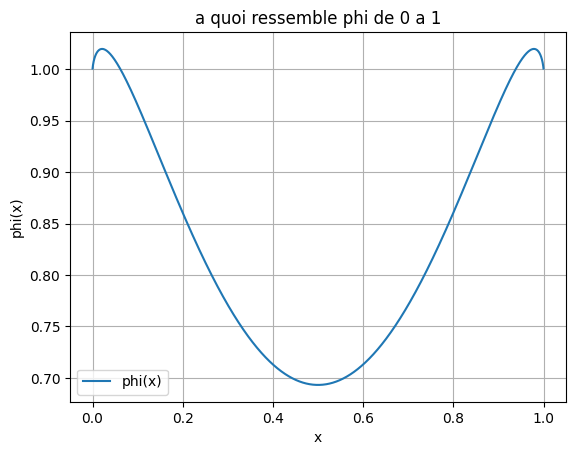

In [ ]:
N = 100000 #nb de sites
T = 1 #température en Kelvin
J0 = 2 # 
B0 = 0  #champ magnétique
J = J0/N # J normalisé
B = B0  #B normalisé


def xi(x) : 
    return (1-x)*np.log(1-x)+x*np.log(x) 

def energie(x) : 
    return (J0*(2*x-1)**2 + 2*B0*(2*x-1))/(2*T)

def phi(x) :
    return - xi(x) + energie(x)

fig = plt.figure()

X = np.linspace(0, 1, 10000)
Y_xi= - xi(X)
Y_energie =   energie(X)
Y_phi =  phi(X)

plt.plot(X, Y_phi, label = 'phi(x)')
#plt.plot(X, Y_xi, linestyle = '--', label = 'xi(x)')
#plt.plot(X, Y_energie, linestyle = '--', label = 'energie(x)')
plt.xlabel('x')
plt.ylabel('phi(x)')
plt.title('a quoi ressemble phi de 0 a 1')
plt.legend()
plt.grid('True')
plt.show()

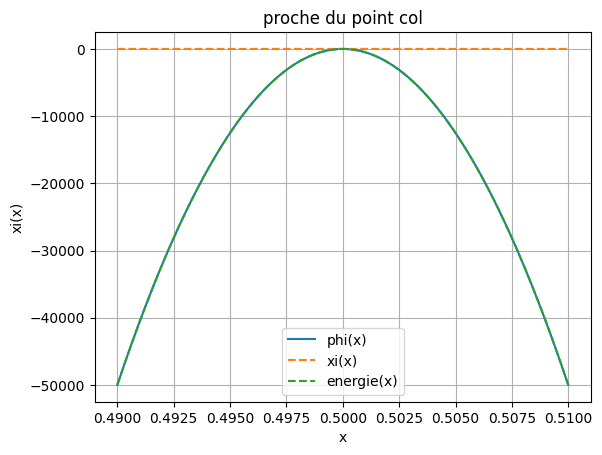

In [18]:
X = np.linspace(0.49, 0.51, 10000)

plt.plot(X, Y_phi, label = 'phi(x)')
plt.plot(X, Y_xi, linestyle = '--', label = 'xi(x)')
plt.plot(X, Y_energie, linestyle = '--', label = 'energie(x)')
plt.xlabel('x')
plt.ylabel('xi(x)')
plt.title('proche du point col')
plt.legend()
plt.grid('True')
plt.show()

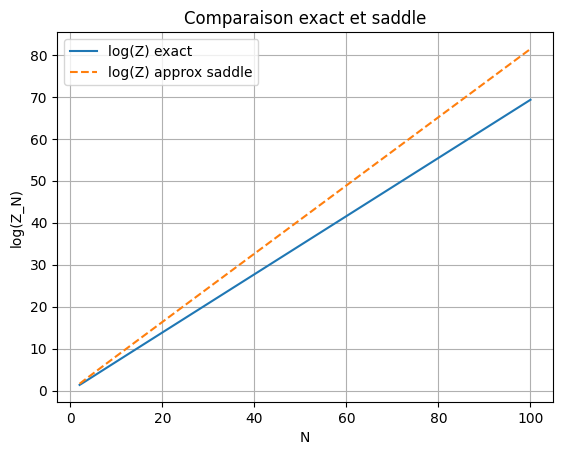

In [73]:
#Z_N en fonction de N mais faux lol 

J0 = 1.0  
B0 = 0.5 
T = 1.0         

def xi(x):
    return (1-x)*np.log(1-x)+x*np.log(x) 

def energie(x, n):
    J = J0/n
    return (J*(2*x-1)**2 + 2*B0*(2*x-1)) / (2*T)

def phi(x, n):
    return -xi(x) + energie(x, n)

def dphi(x, n, h=1e-7): #resultat numerique
    return (phi(x+h, n) - phi(x-h, n)) / (2*h)

def ddphi(x, n): #calcul analytique
    return -1.0/(x*(1-x)) + 4.0*(J0/n)/(T*n)


#Z_N exact
def Z_N_exact_log(n):
    J = J0 / n     
    B = B0         

    log_terms = []
    for k in range(0, n+1):
        x = k / n
        log_comb = np.log(comb(n, k, exact=False))

        magnetisation = 2*x - 1
        energie_k = (J * magnetisation**2 + 2*B * magnetisation) / (2*T)  

        log_terms.append(log_comb + energie_k)

    return - J/(2*T) + logsumexp(log_terms)



# Z_N approximé avec saddle-point method
def Z_N_approx_log(n):
    X_col = brentq(lambda x: dphi(x, n), 0.01, 0.99, maxiter=200)
    return -J0/(2.0*T*n) + n*phi(X_col, n)  - 0.5*np.log(X_col*(1-X_col))- 0.5*np.log(-ddphi(X_col, n))

#plot

NN = np.arange(2, 101)
Y_exact_log = [Z_N_exact_log(n) for n in NN]
Y_approx_log = [Z_N_approx_log(n) for n in NN]

plt.plot(NN, Y_exact_log,  label='log(Z) exact')
plt.plot(NN, Y_approx_log, '--', label='log(Z) approx saddle')
plt.xlabel('N')
plt.ylabel('log(Z_N)')
plt.title('Comparaison exact et saddle')
plt.legend()
plt.grid(True)
plt.show()


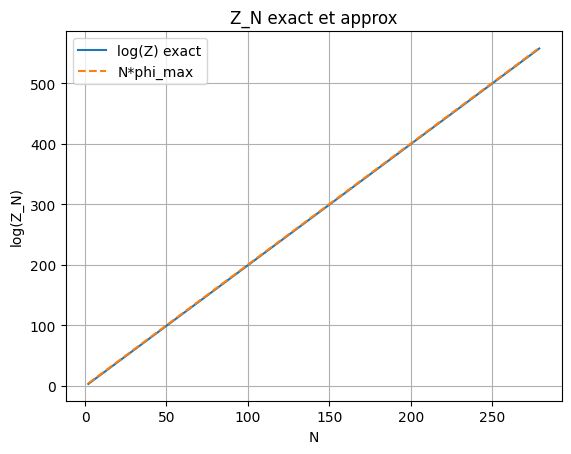

In [ ]:
#Z_N en fonction de N avec une approximation douteuse mais sans integrale
from scipy.optimize import minimize_scalar

J0 = 2.0  
B0 = 1
T = 1.0         

def xi(x) : 
    return (1-x)*np.log(1-x)+x*np.log(x) 

def energie(x) : 
    return (J0*(2*x-1)**2 + 2*B0*(2*x-1))/(2*T)

def phi(x) :
    return - xi(x)+energie(x)

def f(x):
    return 1/np.sqrt(x*(1-x))

# phi max 
res = minimize_scalar(lambda x: -phi(x), bounds=(0,1), method='bounded')
x_col = res.x
phi_max = phi(x_col)



#Z_N exact
def Z_N_exact_log(T):
    k = np.arange(0, N+1)
    x = k / N
    log_terms = np.log(comb(N, k)) + N * (J0*(2*x-1)**2 + 2*B0*(2*x-1)) / (2*T)
    Z_N_log = -J0/(2*T) + logsumexp(log_terms)
    return Z_N_log


#plot

# NN = np.arange(2, 280)
# f_min = f(0.5)                   
# f_max = 1/np.sqrt(1/NN*(1-1/NN))   

# Z_N_log_mega_approx = NN*phi_max
# #Z_N_log_min = -J0/(2*T) + np.log(f_min) + NN * phi_max (approximation moins approximative mais faut gérer son effort)
# #Z_N_log_max = -J0/(2*T) + np.log(f_max) + NN * phi_max
# Y_exact_log = np.array([Z_N_exact_log(n) for n in NN])

# plt.plot(NN, Y_exact_log,  label='log(Z) exact')
# plt.plot(NN, Z_N_log_mega_approx, '--',  label='N*phi_max')
# #plt.plot(NN, Z_N_log_min, '--', label='inf')
# #plt.plot(NN, Z_N_log_max, '--', label='sup')
# plt.xlabel('N')
# plt.ylabel('log(Z_N)')
# plt.title('Z_N exact et approx')
# plt.legend()
# plt.grid(True)
# plt.show()

N = 50
Ts = np.linspace(0.1, 10)
J0 = 2.0
B0 = 1.0

plt.plot(Ts, Z_N_exact_log(Ts))

C:\Users\apeti\AppData\Local\Temp\ipykernel_72756\3298668939.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


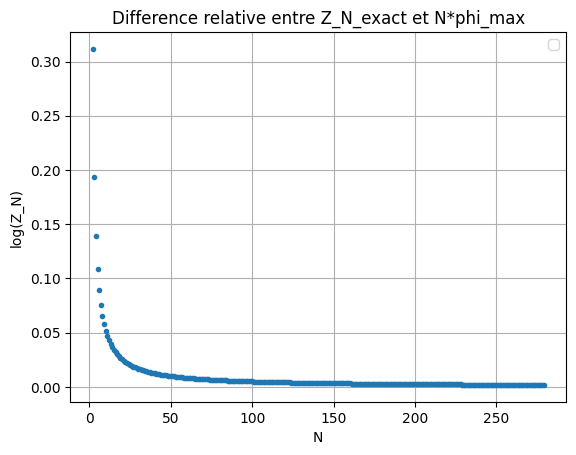

In [55]:
# différence relative 

Y_diff = np.abs(Y_exact_log- Z_N_log_mega_approx) / Y_exact_log

plt.figure()
plt.plot(NN, Y_diff, marker='o', markersize=3, linestyle='None')
plt.xlabel('N')
plt.ylabel('(logZN_exact - N*phi_max) / logZN_exact')
plt.title('Difference relative entre Z_N_exact et N*phi_max')
plt.xlabel('N')
plt.ylabel('log(Z_N)')
plt.legend()
plt.grid(True)
plt.show()


In [60]:
J0 = 20
B0 = 0
T  = 1

def dphi(x):
    return np.log(x/(1-x)) - (2*J0*(2*x-1) + 2*B0)/T

x_col = brentq(dphi, 1e-6, 1-1e-6)
phi_max = phi(x_col)

print(f"x_col = {x_col:.6f}")
print(f"phi_max = {phi_max:.6f}")


x_col = 0.500000
phi_max = 0.693147


## Condition sur B pour avoir 3 points fixes

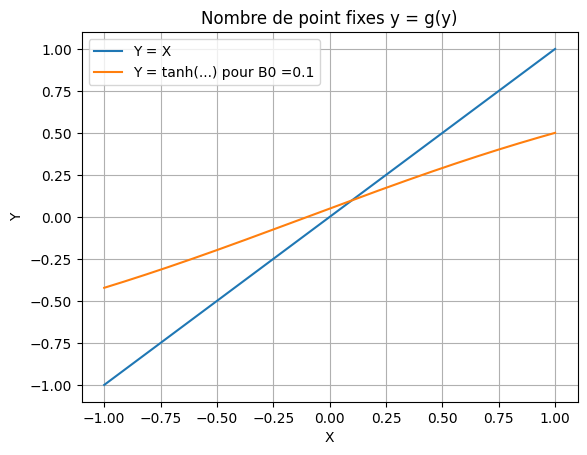

In [7]:
#determiner le nombre de solutions de l'equation y = tanh(J0 beta y + B0 beta) = g(y)
T = 2
J0 = 1
B0 = 1*10**(-1)

X = np.linspace(-1+10**(-12), 1- 10**(-12), 1000)
Y = np.tanh(J0*X/T+B0/T)

plt.plot(X, X, label='Y = X')
plt.plot(X, Y, label=f'Y = tanh(...) pour B0 ={B0}')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Nombre de point fixes y = g(y)')
plt.legend()
plt.grid(True)
plt.show()

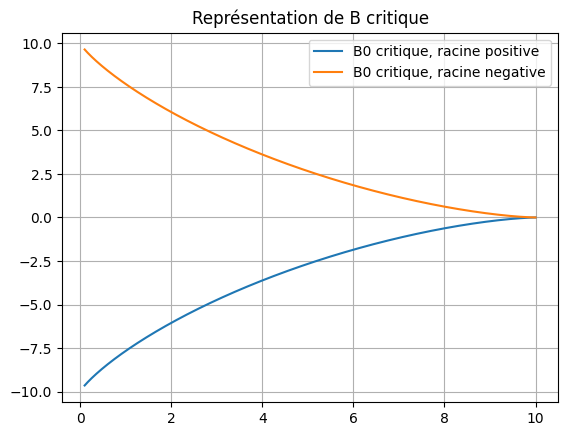

In [19]:
#on fixe J0 et on trace B critique en fonction de T avec J0>=T 
J0 = 10

T = np.linspace(0.1, 10, 1000)

B0_critique_pos = T*np.arctanh(np.sqrt(1 - T / J0)) - J0 * np.sqrt(1 - T / J0)
B0_critique_neg = T*np.arctanh(- np.sqrt(1 - T / J0)) + J0 * np.sqrt(1 - T / J0)


plt.plot( T, B0_critique_pos, label = 'B0 critique, racine positive' )
plt.plot( T, B0_critique_neg, label = 'B0 critique, racine negative' )
plt.title( 'Représentation de B critique' )
plt.legend()
plt.grid(True)
plt.show()
#si B est dans la pointe on a 3 points fixes, si il est au dessus/en dessous, on en a 1 seul

C:\Users\apeti\AppData\Local\Temp\ipykernel_16944\3317648703.py:14: RuntimeWarning: divide by zero encountered in arctanh
  B_critique = T_critique * np.arctanh(m) - J0 * m
C:\Users\apeti\AppData\Local\Temp\ipykernel_16944\3317648703.py:15: RuntimeWarning: divide by zero encountered in arctanh
  B_inf_J0 = T_inf_J0 * np.arctanh(m) - J0 * m
C:\Users\apeti\AppData\Local\Temp\ipykernel_16944\3317648703.py:16: RuntimeWarning: divide by zero encountered in arctanh
  B_sup_J0 = T_sup_J0 * np.arctanh(m) - J0 * m


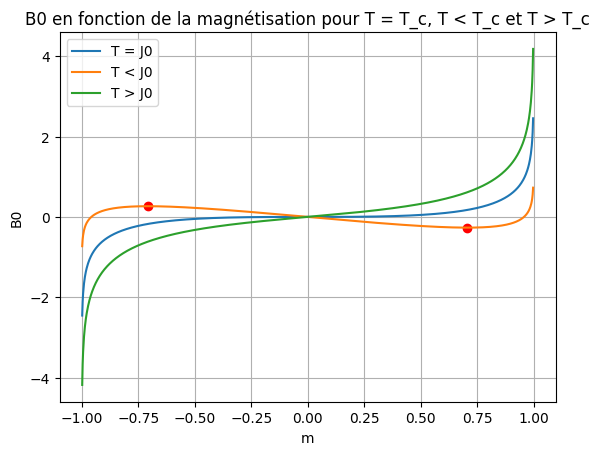

In [73]:
#tracons B0 en fonction de m pour T et J0 fixé

J0 = 1
T_critique = J0
T_inf_J0 = 0.5 * J0
T_sup_J0 = 1.5 * J0

m = np.linspace(-1, 1, 1000) #x entre 0 et 1 donc m = 2x-1 entre -1 et 1

B0_critique_pos = T_inf_J0 * np.arctanh(np.sqrt(1 - T_inf_J0 / J0)) - J0 * np.sqrt(1 - T_inf_J0 / J0)
B0_critique_neg = T_inf_J0 * np.arctanh(- np.sqrt(1 - T_inf_J0 / J0)) - J0 * (- np.sqrt(1 - T_inf_J0 / J0))


B_critique = T_critique * np.arctanh(m) - J0 * m
B_inf_J0 = T_inf_J0 * np.arctanh(m) - J0 * m
B_sup_J0 = T_sup_J0 * np.arctanh(m) - J0 * m

plt.plot([np.sqrt(1 - T_inf_J0 / J0)], [B0_critique_pos], 'ro')
plt.plot([-np.sqrt(1 - T_inf_J0 / J0)], [B0_critique_neg], 'ro')

plt.plot(m, B_critique, label=f'T = J0')
plt.plot(m, B_inf_J0, label = f'T < J0')
plt.plot(m, B_sup_J0, label = f'T > J0')
plt.xlabel('m')
plt.ylabel('B0')
plt.legend()
plt.title('B0 en fonction de la magnétisation pour T = T_c, T < T_c et T > T_c')
plt.grid(True)
plt.show()